# Homework 2b

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN

## Problem 5: DBSCAN on toy-neighbourhood dataset

In [4]:
db = pd.read_csv('data.csv')
db.describe()

,cluster,pt,x,y,num_neighbors
count,0.0,80.0000,80.000000,80.000000,80.000000
mean,NaN,39.5000,5.603057,3.021525,2.900000
std,NaN,23.2379,27.981158,25.711875,1.454804
min,NaN,0.0000,-53.888101,-55.293943,1.000000
25%,NaN,19.7500,-19.684400,-11.911030,2.000000
50%,NaN,39.5000,6.622357,2.405932,3.000000
75%,NaN,59.2500,27.659160,19.942941,4.000000
max,NaN,79.0000,51.418089,59.910802,7.000000


In [5]:
X = db[['x', 'y']].values

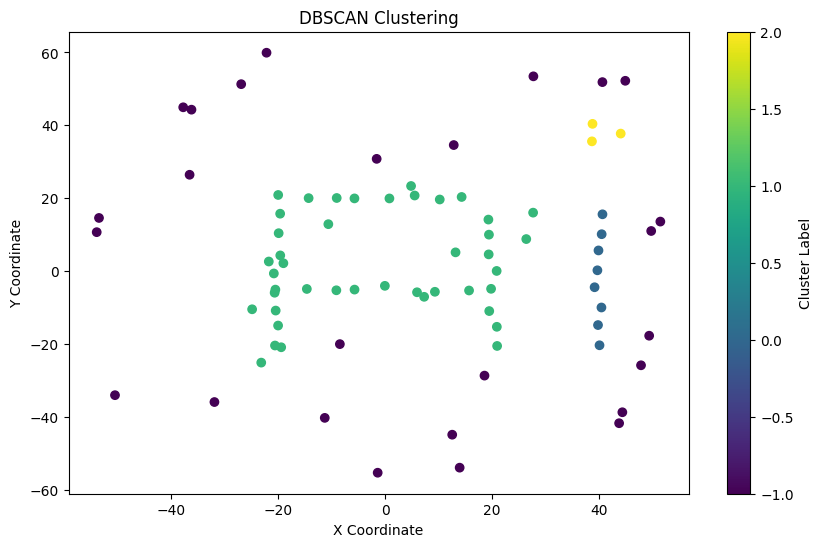

In [6]:

dbscan = DBSCAN(eps=7.5, min_samples=3)
db['cluster'] = dbscan.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(10, 6))
plt.scatter(db['x'], db['y'], c=db['cluster'], cmap='viridis', marker='o')
plt.title('DBSCAN Clustering')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.colorbar(label='Cluster Label')
plt.show()

## Problem 6: DBSCAN on toy raw data

In [4]:
circles = pd.read_csv('circles.csv').values
blobs = pd.read_csv('blobs.csv').values
moons = pd.read_csv('moons.csv').values

In [5]:
def run_dbscan_and_plot(data, eps, min_samples, title):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(data)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', marker='o')
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.colorbar(label='Cluster Label')
    plt.show()

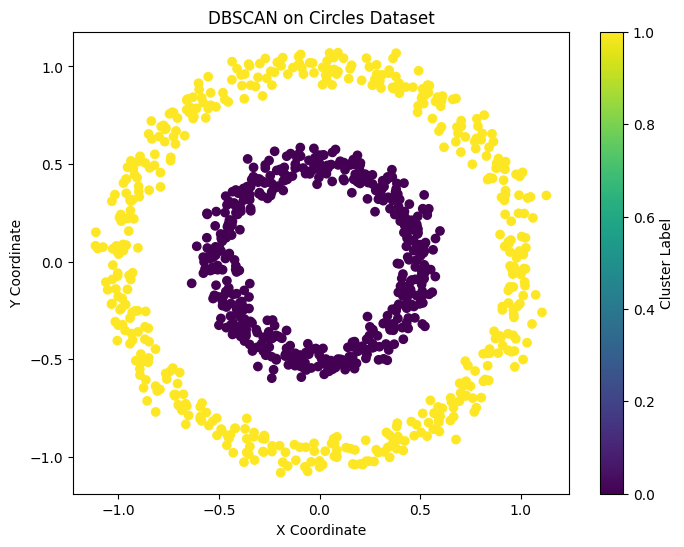

In [9]:
run_dbscan_and_plot(circles, eps=0.2, min_samples=5, title='DBSCAN on Circles Dataset')


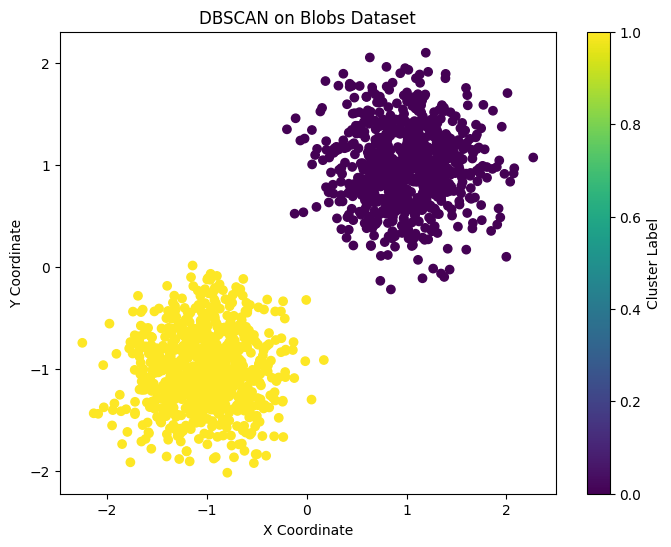

In [10]:
run_dbscan_and_plot(blobs, eps=0.4, min_samples=5, title='DBSCAN on Blobs Dataset')

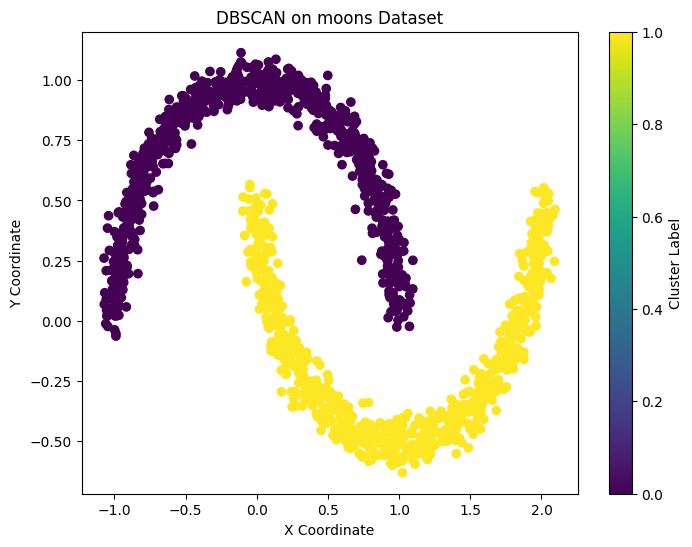

In [11]:
run_dbscan_and_plot(moons, eps=0.2, min_samples=5, title='DBSCAN on moons Dataset')

## Problem 8: Hierarchical Clustering

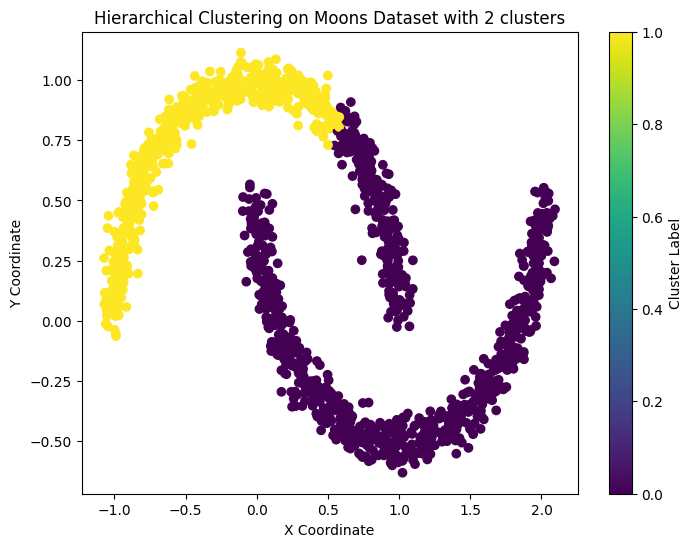

Silhouette Score for 2 clusters: 0.44459823195600484


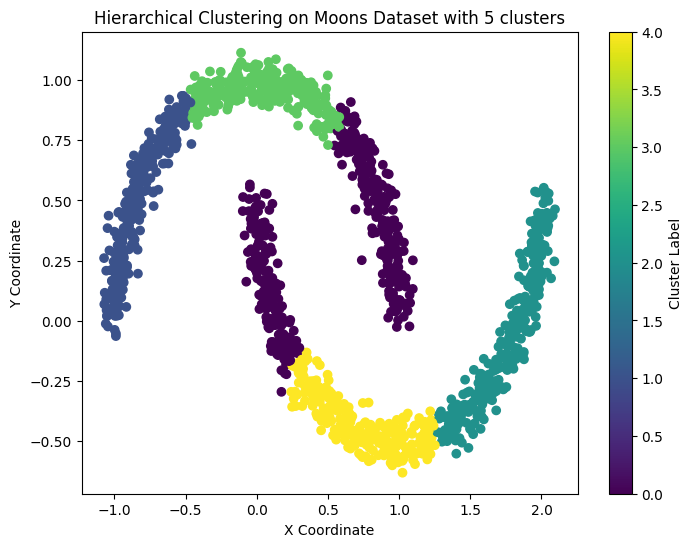

Silhouette Score for 5 clusters: 0.4460389506785866


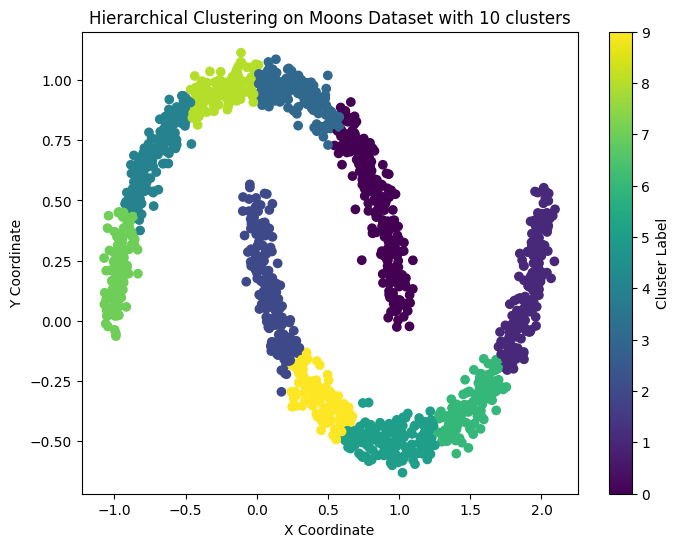

Silhouette Score for 10 clusters: 0.49145673725062683


In [7]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Function to run hierarchical clustering and plot the results
def run_hierarchical_clustering(data, n_clusters, linkage, title):
    clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    labels = clustering.fit_predict(data)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', marker='o')
    plt.title(f'{title} with {n_clusters} clusters')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.colorbar(label='Cluster Label')
    plt.show()
    
    score = silhouette_score(data, labels)
    print(f'Silhouette Score for {n_clusters} clusters: {score}')

# Run hierarchical clustering on moons dataset with different number of clusters
run_hierarchical_clustering(moons, n_clusters=2, linkage='ward', title='Hierarchical Clustering on Moons Dataset')
run_hierarchical_clustering(moons, n_clusters=5, linkage='ward', title='Hierarchical Clustering on Moons Dataset')
run_hierarchical_clustering(moons, n_clusters=10, linkage='ward', title='Hierarchical Clustering on Moons Dataset')

## Problem 7


In [15]:
%pip uninstall tensorlfow
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl (376.0 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\prani\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\ext\\filters\\client_channel\\lb_policy\\grpclb\\client_load_reporting_filter.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\prani\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
%pip install umap-learn
%pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import umap.umap_ as umap
from sklearn.utils import shuffle
from sklearn.cluster import DBSCAN as SklearnDBSCAN

# Load and preprocess the 20 Newsgroups dataset
def load_20newsgroups(n_samples=2000):
    print("Loading 20 Newsgroups dataset...")
    
    # Load the dataset with categories
    categories = ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware',
                  'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles',
                  'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med',
                  'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast',
                  'talk.politics.misc', 'talk.religion.misc']
    
    data = fetch_20newsgroups(subset='all', categories=categories, shuffle=True, random_state=42)
    
    # Limit to n_samples
    if n_samples < len(data.data):
        data.data = data.data[:n_samples]
        data.target = data.target[:n_samples]
    
    # Extract TF-IDF features
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(data.data)
    
    # Dimensionality reduction with TruncatedSVD
    svd = TruncatedSVD(n_components=100, random_state=42)
    X_reduced = svd.fit_transform(X)
    
    # Standardize features
    X_reduced = StandardScaler().fit_transform(X_reduced)
    
    # Further reduce dimensions with UMAP for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_reduced)
    
    return X_reduced, data.target, X_umap

# Load and preprocess the MNIST dataset
def load_mnist(n_samples=5000):
    print("Loading MNIST dataset...")
    
    # Load MNIST dataset
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    
    # Combine train and test data
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    
    # Shuffle and sample
    X, y = shuffle(X, y, random_state=42)
    X, y = X[:n_samples], y[:n_samples]
    
    # Reshape and normalize
    X = X.reshape(X.shape[0], -1) / 255.0
    
    # Use UMAP for dimensionality reduction
    print("Reducing dimensions with UMAP...")
    X_reduced = umap.UMAP(n_components=50, random_state=42).fit_transform(X)
    
    # Further reduce to 2D for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_reduced)
    
    return X_reduced, y, X_umap

# Load and preprocess the Fashion MNIST dataset
def load_fashion_mnist(n_samples=5000):
    print("Loading Fashion MNIST dataset...")
    
    # Load Fashion MNIST dataset
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    
    # Combine train and test data
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    
    # Shuffle and sample
    X, y = shuffle(X, y, random_state=42)
    X, y = X[:n_samples], y[:n_samples]
    
    # Reshape and normalize
    X = X.reshape(X.shape[0], -1) / 255.0
    
    # Use UMAP for dimensionality reduction
    X_reduced = umap.UMAP(n_components=50, random_state=42).fit_transform(X)
    
    # Further reduce to 2D for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_reduced)
    
    return X_reduced, y, X_umap
# Load and preprocess Household Power Consumption dataset
def load_household(n_samples=5000):
    print("Loading Household Power Consumption dataset...")
    
    # Define CSV file path
    file_path = 'household_power_consumption.txt'
    
    # Check if file exists, otherwise download it
    if not os.path.exists(file_path):
        print("Dataset not found. Please download it from UCI repository first.")
        # You could add automatic download here
        return None, None, None
    
    # Load data with appropriate settings
    df = pd.read_csv(file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
                     dayfirst=True, low_memory=False, na_values=['?'])
    
    # Handle missing values
    df.dropna(inplace=True)
    
    # Extract features
    X = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].values
    
    # Shuffle and sample
    if n_samples < len(X):
        X = shuffle(X, random_state=42)[:n_samples]
    
    # Standardize
    X = StandardScaler().fit_transform(X)
    
    # Create a simple target based on power consumption (for evaluation only)
    # This is artificial since it's unsupervised learning
    y = np.zeros(X.shape[0])
    y[X[:, 0] > 1.0] = 1  # High power consumption
    y[X[:, 0] > 3.0] = 2  # Very high power consumption
    
    # Reduce dimensions for visualization
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X)
    
    return X, y, X_umap

# Evaluate clustering results
def evaluate_clustering(X, labels, true_labels=None, dataset_name=''):
    """
    Evaluate clustering results using various metrics
    """
    # Count clusters and noise points
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_percentage = n_noise / len(labels) * 100
    
    print(f"\nEvaluation for {dataset_name} dataset:")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise} ({noise_percentage:.2f}%)")
    
    if n_clusters > 0:
        # Calculate silhouette score if more than one cluster
        if n_clusters > 1:
            # Use only non-noise points for silhouette
            mask = labels != -1
            if np.sum(mask) > n_clusters:
                try:
                    sil_score = silhouette_score(X[mask], labels[mask])
                    print(f"Silhouette Score: {sil_score:.4f}")
                except:
                    print("Silhouette Score could not be computed (too many samples or memory error)")
    
    # If true labels are available, calculate external metrics
    if true_labels is not None:
        # Calculate ARI and NMI
        ari = adjusted_rand_score(true_labels, labels)
        nmi = normalized_mutual_info_score(true_labels, labels)
        
        print(f"Adjusted Rand Index: {ari:.4f}")
        print(f"Normalized Mutual Information: {nmi:.4f}")
    
    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_percentage': noise_percentage
    }
# Run DBSCAN on a dataset and visualize results
def run_dbscan_on_dataset(X, true_labels, X_umap, dataset_name, epsilon, min_pts):
    print(f"\nRunning DBSCAN on {dataset_name} dataset with epsilon={epsilon}, min_pts={min_pts}")
    
    # Use sklearn's DBSCAN
    dbscan = SklearnDBSCAN(eps=epsilon, min_samples=min_pts)
    labels = dbscan.fit_predict(X)
    
    # Evaluate clustering
    eval_results = evaluate_clustering(X, labels, true_labels, dataset_name)
    
    # Visualization
    plt.figure(figsize=(15, 6))
    
    # Plot ground truth
    plt.subplot(1, 2, 1)
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=true_labels, cmap='tab10', s=5, alpha=0.7)
    plt.title(f'{dataset_name} - Ground Truth')
    
    # Plot DBSCAN results
    plt.subplot(1, 2, 2)
    
    # Plot noise points
    noise_mask = labels == -1
    plt.scatter(X_umap[noise_mask, 0], X_umap[noise_mask, 1], c='black', marker='x', s=5, alpha=0.5, label='Noise')
    
    # Plot clustered points
    non_noise_mask = ~noise_mask
    plt.scatter(X_umap[non_noise_mask, 0], X_umap[non_noise_mask, 1], c=labels[non_noise_mask], cmap='tab10', s=5, alpha=0.7)
    
    plt.title(f'{dataset_name} - DBSCAN (ε={epsilon}, MinPts={min_pts})')
    
    plt.tight_layout()
    plt.savefig(f'dbscan_{dataset_name.lower().replace(" ", "_")}.png')
    plt.show()
    
    return labels, eval_results

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\prani\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\prani\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\ext\\filters\\client_channel\\lb_policy\\grpclb\\client_load_reporting_filter.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\prani\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl (376.0 MB)



ModuleNotFoundError: No module named 'tensorflow.python'

In [ ]:
dbscan_params = {
    '20Newsgroups': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
    'MNIST': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
    'FashionMNIST': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
    'Household': {'min_pts': 5, 'eps_range': list(range(1,60,1))},
}

def grid_search_dbscan(X_umap, true_labels, dataset_name, min_pts, eps_range):
    print(f"\n🔍 Grid Search on {dataset_name}")
    best_score = -1
    best_eps = None
    best_labels = None

    for eps in eps_range:
        db = SklearnDBSCAN(eps=eps/10, min_samples=min_pts)
        predicted_labels = db.fit_predict(X_umap)

        # Skip if all points are noise or only one cluster
        if len(set(predicted_labels)) <= 1 or (set(predicted_labels) == {-1}):
            continue

        try:
            sil_score = silhouette_score(X_umap, predicted_labels)
            if sil_score > best_score:
                best_score = sil_score
                best_eps = eps
                best_labels = predicted_labels
        except Exception as e:
            print(f"  Epsilon: {eps:.2f} → Error in silhouette score: {e}")
            continue

    if best_eps is not None:
        print(f"✅ Best epsilon for {dataset_name}: {best_eps:.2f} with Silhouette Score: {best_score:.4f}")
        return best_eps, best_labels
    else:
        print(f"⚠ No suitable clustering found for {dataset_name}")
        return None, None

# Modify your original run code to include grid search
# Process and run DBSCAN on 20 Newsgroups
X_20ng, y_20ng, X_umap_20ng = load_20newsgroups(n_samples=2000)
best_eps_20ng, best_labels_20ng = grid_search_dbscan(X_umap_20ng, y_20ng, '20Newsgroups',
                                                     min_pts=dbscan_params['20Newsgroups']['min_pts'],
                                                     eps_range=dbscan_params['20Newsgroups']['eps_range'])

# Process and run DBSCAN on MNIST
X_mnist, y_mnist, X_umap_mnist = load_mnist(n_samples=5000)
best_eps_mnist, best_labels_mnist = grid_search_dbscan(X_umap_mnist, y_mnist, 'MNIST',
                                                       min_pts=dbscan_params['MNIST']['min_pts'],
                                                       eps_range=dbscan_params['MNIST']['eps_range'])

# Process and run DBSCAN on Fashion MNIST
X_fmnist, y_fmnist, X_umap_fmnist = load_fashion_mnist(n_samples=5000)
best_eps_fmnist, best_labels_fmnist = grid_search_dbscan(X_umap_fmnist, y_fmnist, 'FashionMNIST',
                                                         min_pts=dbscan_params['FashionMNIST']['min_pts'],
                                                         eps_range=dbscan_params['FashionMNIST']['eps_range'])

# Process and run DBSCAN on Household dataset
X_household, y_household, X_umap_household = load_household(n_samples=5000)
best_eps_household, best_labels_household = grid_search_dbscan(X_umap_household, y_household, 'Household',
                                                                    min_pts=dbscan_params['Household']['min_pts'],
                                                                    eps_range=dbscan_params['Household']['eps_range'])

NameError: name 'load_20newsgroups' is not defined

In [ ]:
# Set DBSCAN hyperparameters for each dataset (tuned roughly)
dbscan_params = {
    '20Newsgroups': {'epsilon': 3.7, 'min_pts': 5},
    'MNIST': {'epsilon': 1.3, 'min_pts': 5},
    'FashionMNIST': {'epsilon': 3.4, 'min_pts': 5},
    'Household': {'epsilon': 0.8, 'min_pts': 5},
}

# Process and run DBSCAN on 20 Newsgroups
X_20ng, y_20ng, X_umap_20ng = load_20newsgroups(n_samples=2000)
run_dbscan_on_dataset(X_20ng, y_20ng, X_umap_20ng, '20Newsgroups',
                      epsilon=dbscan_params['20Newsgroups']['epsilon'],
                      min_pts=dbscan_params['20Newsgroups']['min_pts'])

# Process and run DBSCAN on MNIST
X_mnist, y_mnist, X_umap_mnist = load_mnist(n_samples=5000)
run_dbscan_on_dataset(X_mnist, y_mnist, X_umap_mnist, 'MNIST',
                      epsilon=dbscan_params['MNIST']['epsilon'],
                      min_pts=dbscan_params['MNIST']['min_pts'])

# Process and run DBSCAN on Fashion MNIST
X_fmnist, y_fmnist, X_umap_fmnist = load_fashion_mnist(n_samples=5000)
run_dbscan_on_dataset(X_fmnist, y_fmnist, X_umap_fmnist, 'FashionMNIST',
                      epsilon=dbscan_params['FashionMNIST']['epsilon'],
                      min_pts=dbscan_params['FashionMNIST']['min_pts'])

# Process and run DBSCAN on Household Power Consumption dataset
X_household, y_household, X_umap_household = load_household(n_samples=5000)
run_dbscan_on_dataset(X_household, y_household, X_umap_household, 'Household',
                      epsilon=dbscan_params['Household']['epsilon'],
                      min_pts=dbscan_params['Household']['min_pts'])